In [1]:
pip install jee_data_base

In [ ]:
pip install pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=757856d9e5bb500fb976e80f5493dbaf5e891ef0c9ab2b6bd3d62f866a8b2a35
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
ERROR: Operation cancelled by user
^C


In [ ]:
from jee_data_base import DataBase, Filter
import pandas as pd

db = DataBase()
# Use the chapters_dict to get our "Subtopics" master list
filter_engine = Filter(db.chapters_dict)

all_extracted_data = []

# 2. Get all available chapters
chapters = filter_engine.get_possible_filter_values()["chapter"]

print(f"Extracting data for {len(chapters)} chapters...")

for chap in chapters:
    # Get all questions for this chapter
    # We take all years available to build a strong historical baseline
    questions = filter_engine.by_chapter(chap).get()

    for q in questions:
        # q is a Question object from the library
        # We extract the features needed for our ML models
        all_extracted_data.append({
            'Question_Text': q.question,
            'Subject': q.subject,
            'Chapter': q.chapter,
            'Topic': q.topic, # This is our "Subtopic" for the SQL schema
            'Year': q.year,
            'Is_Numerical': 1 if "integer" in q.type.lower() else 0,
            # We can calculate an initial complexity based on text length or LaTeX symbols
            'Initial_Complexity': len(q.question.split())
        })

# 3. Convert to DataFrame for a quick look
df = pd.DataFrame(all_extracted_data)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


/usr/local/lib/python3.12/dist-packages/jee_data_base/cache/123-DataBaseChapters-v007.pkl: 100%|██████████| 24.2M/24.2M [00:00<00:00, 218MB/s]
/usr/local/lib/python3.12/dist-packages/jee_data_base/cache/123-EmbeddingsChapters-v007.pkl: 100%|██████████| 138M/138M [00:01<00:00, 110MB/s]
Unpickling: core.chapter Chapter
Unpickling: core.question Question
Extracting data for 91 chapters...
                                       Question_Text      Subject  \
0  Let $$\alpha ,\,\beta $$ be such that $$\pi  &...  mathematics   
1  If  $$u = \sqrt {{a^2}{{\cos }^2}\theta  + {b^...  mathematics   
2  If $$0 &lt; x &lt; \pi $$ and $$\cos x + \sin ...  mathematics   
3  Let <b>A</b> and <b>B</b> denote the statement...  mathematics   
4  Let $$\cos \left( {\alpha  + \beta } \right) =...  mathematics   

                             Chapter                             Topic  Year  \
0  trigonometric-ratio-and-identites  addition-and-subtraction-formula  2004   
1  trigonometric-ratio-and-identites

In [ ]:
df.head()

,Question_Text,Subject,Chapter,Topic,Year,Is_Numerical,Initial_Complexity
0,"Let $$\alpha ,\,\beta $$ be such that $$\pi &...",mathematics,trigonometric-ratio-and-identites,addition-and-subtraction-formula,2004,0,50
1,If $$u = \sqrt {{a^2}{{\cos }^2}\theta + {b^...,mathematics,trigonometric-ratio-and-identites,range-of-trigonometric-functions,2004,0,34
2,If $$0 &lt; x &lt; \pi $$ and $$\cos x + \sin ...,mathematics,trigonometric-ratio-and-identites,fundamental-identities,2006,0,22
3,Let <b>A</b> and <b>B</b> denote the statement...,mathematics,trigonometric-ratio-and-identites,addition-and-subtraction-formula,2009,0,59
4,Let $$\cos \left( {\alpha + \beta } \right) =...,mathematics,trigonometric-ratio-and-identites,addition-and-subtraction-formula,2010,0,37


In [ ]:
import re
import pandas as pd
from pylatexenc.latex2text import LatexNodes2Text
from jee_data_base import DataBase, Filter

# --- 1. THE SQL-SAFE MATH CLEANER ---
def clean_math_text(raw_text):
    """
    Refined cleaner to preserve statement structures like "Let A and B..."
    while making the string safe for MS SQL ingestion.
    """
    if not raw_text:
        return ""

    # 1. First, try a soft LaTeX-to-Text conversion to handle basic symbols
    try:
        # We use a lower level of 'stripping' to keep the structure
        readable_text = LatexNodes2Text().latex_to_text(raw_text)
    except:
        readable_text = raw_text

    # 2. SQL SAFETY: MS SQL uses single quotes (') to denote strings.
    # If a question says "Farmer's loop", it will break the SQL command.
    # We replace ' with '' (SQL escape for single quotes).
    safe_text = readable_text.replace("'", "''")

    # 3. Preserve Newlines and Tabs for readability in the UI
    safe_text = safe_text.replace("\n", " ").replace("\r", " ")

    # 4. Remove excessive backslashes that might be interpreted as escape chars in Python
    safe_text = re.sub(r'\\+', r'\\', safe_text)

    return safe_text.strip()

# --- 2. THE FEATURE ENGINEER (The 'Out of the Box' part) ---
def get_ml_features(raw_latex):
    """
    Captures cross-subject signals and complexity markers.
    """
    return {
        # General Complexity Signals
        'symbol_count': len(re.findall(r'\\[a-zA-Z]+', raw_latex)),
        'char_count': len(raw_latex),

        # Mathematical Signals
        'has_integral': 1 if r'\int' in raw_latex else 0,
        'has_differentiation': 1 if r'\frac{d}{d' in raw_latex or r'f\'' in raw_latex else 0,
        'has_matrix_or_det': 1 if any(x in raw_latex.lower() for x in ['matrix', 'det', 'vmatrix']) else 0,
        'has_vector': 1 if any(x in raw_latex for x in [r'\vec', r'\hat', r'\mathbf']) else 0,

        # Physics & Chemistry Specific Signals
        'has_units': 1 if re.search(r'm/s|kg|mol|Joules|Tesla|Volt', raw_latex, re.IGNORECASE) else 0,
        'has_chemical_formula': 1 if re.search(r'H2|O2|CO2|Fe|Cu|SO4|NH3', raw_latex) else 0,

        # Conceptual Complexity
        'is_multi_concept': 1 if (r'\int' in raw_latex and any(x in raw_latex for x in [r'\vec', 'kg', 'mol'])) else 0
    }

# --- 3. THE EXTRACTION LOOP ---
def extract_and_transform():
    db = DataBase()
    filter_engine = Filter(db.chapters_dict)

    processed_data = []
    chapters = filter_engine.get_possible_filter_values()["chapter"]

    print(f"Starting extraction for {len(chapters)} chapters...")

    for chap_name in chapters:
        # Get all questions for this chapter
        questions = filter_engine.by_chapter(chap_name).get()

        for q in questions:
            # A. Clean the text for SQL and preserve bold/statement structure
            display_text = clean_math_text(q.question)

            # B. Extract numeric signals for the ML model
            ml_signals = get_ml_features(q.question)

            # C. Combine everything into one dictionary
            record = {
                'Question_Text': display_text,
                'Raw_Latex': q.question,      # Keep original for model transparency
                'Subject': q.subject,
                'Chapter': q.chapter,
                'Subtopic': q.topic,
                'Year': int(q.year),
                'Is_Numerical': 1 if "integer" in q.type.lower() else 0,

                # Merge the ML features
                **ml_signals
            }
            processed_data.append(record)

    return pd.DataFrame(processed_data)

# --- EXECUTION ---
if __name__ == "__main__":
    df = extract_and_transform()

    print("\n--- Preview of Dataset (Sanity Check) ---")
    # Verify that we are catching integration across all subjects
    print(df.groupby('Subject')['has_integral'].sum().reset_index())

    # Check if we preserved the text properly
    print("\nSample Cleaned Text:")
    print(df['Question_Text'].iloc[0][:100] + "...")

Unpickling: core.chapter Chapter
Unpickling: core.question Question
Starting extraction for 91 chapters...

--- Preview of Dataset (Sanity Check) ---
       Subject  has_integral
0  mathematics             0

Sample Cleaned Text:
Let      α , β  be such that      π   lt; α  - β   lt; 3π . <br>If      sin 1muα  + sinβ  =  - 2165 ...


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylatexenc.latex2text import LatexNodes2Text
from jee_data_base import DataBase, Filter

In [ ]:
db = DataBase()
filter_engine = Filter(db.chapters_dict)

print("Available filters:")
print(filter_engine.get_possible_filter_values().keys())

print("\nSubjects available:")
print(filter_engine.get_possible_filter_values().get("subject"))

Unpickling: core.chapter Chapter
Unpickling: core.question Question
Available filters:
dict_keys(['examGroup', 'exam', 'subject', 'chpaterGroup', 'chapter', 'year', 'paperTitle', 'difficulty', 'topic', 'type', 'examDate', 'isOutOfSyllabus', 'isBonus'])

Subjects available:
['mathematics', 'physics', 'chemistry']


In [ ]:
print(dir(db))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'chapters_dict', 'name', 'state', 'subject_map']


In [ ]:
chap = list(db.chapters_dict.values())[0]

print(dir(chap))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'name', 'parent_subject', 'question_dict', 'question_dict_status', 'total_questions']


In [ ]:
for k, v in db.chapters_dict.items():
    print(k, type(v))
    break

trigonometric-ratio-and-identites <class 'jee_data_base.core.chapter.Chapter'>


In [ ]:
import pandas as pd
import re

print("🚀 Extracting FULL JEE dataset...")

db = DataBase()
all_questions = []

total_count = 0

for chap_name, chap in db.chapters_dict.items():
    subject = getattr(chap, "parent_subject", "Unknown")

    # Access the real data directly from the question dictionary
    q_dict = getattr(chap, "question_dict", {})
    if not q_dict:
        continue

    print(f"📘 {chap_name} ({subject}) → {len(q_dict)} questions")

    for q_id, q in q_dict.items():
        raw_latex = getattr(q, "question", "")

        # Feature Engineering based on updated logic
        if not raw_latex:
            ml_features = {
                'symbol_count': 0, 'char_count': 0, 'has_integral': 0,
                'has_diff': 0, 'has_vec': 0, 'has_units': 0,
                'has_chem_terms': 0, 'is_multi_concept': 0
            }
        else:
            ml_features = {
                'symbol_count': len(re.findall(r'\\[a-zA-Z]+', raw_latex)),
                'char_count': len(raw_latex),
                'has_integral': 1 if r'\int' in raw_latex else 0,
                'has_diff': 1 if any(x in raw_latex for x in [r'\frac{d}{d', r"f'("]) else 0,
                'has_vec': 1 if any(x in raw_latex for x in [r'\vec', r'\hat', r'\mathbf']) else 0,
                'has_units': 1 if re.search(r'm/s|kg|Tesla|Volt|Ohm|Watt', raw_latex, re.IGNORECASE) else 0,
                # Refined Chemistry terms to prevent Physics overlap
                'has_chem_terms': 1 if re.search(r'mol|pH|ΔH|K_eq|equilibrium', raw_latex, re.IGNORECASE) else 0,
                'is_multi_concept': 1 if (
                    (r'\int' in raw_latex and re.search(r'kg|m/s|Tesla', raw_latex)) or
                    re.search(r'mol|pH|ΔH|K_eq', raw_latex)
                ) else 0
            }

        row = {
            'Subject': subject.title() if subject else "Unknown",
            'Chapter': chap_name,
            'Subtopic': getattr(q, "topic", "Unknown"),
            'Year': int(q.year) if hasattr(q, "year") and q.year else None,
            'Raw_Latex': raw_latex,
            'Is_Numerical': 1 if hasattr(q, "type") and "integer" in q.type.lower() else 0
        }

        row.update(ml_features)
        all_questions.append(row)
        total_count += 1

print(f"\n✅ Total extracted questions: {total_count}")
# Create DataFrame
df = pd.DataFrame(all_questions)

print(df['Subject'].value_counts())

# Save
df.to_csv('jee_full_dataset.csv', index=False)

print("💾 Saved as jee_full_dataset.csv")

🚀 Extracting FULL JEE dataset...
Unpickling: core.chapter Chapter
Unpickling: core.question Question
📘 trigonometric-ratio-and-identites (Mathematics) → 57 questions
📘 matrices-and-determinants (Mathematics) → 342 questions
📘 probability (Mathematics) → 217 questions
📘 logarithm (Mathematics) → 8 questions
📘 differentiation (Mathematics) → 81 questions
📘 differential-equations (Mathematics) → 225 questions
📘 straight-lines-and-pair-of-straight-lines (Mathematics) → 165 questions
📘 mathematical-induction (Mathematics) → 3 questions
📘 vector-algebra (Physics) → 38 questions
📘 height-and-distance (Mathematics) → 41 questions
📘 binomial-theorem (Mathematics) → 235 questions
📘 indefinite-integrals (Mathematics) → 83 questions
📘 functions (Mathematics) → 156 questions
📘 parabola (Mathematics) → 137 questions
📘 definite-integration (Mathematics) → 300 questions
📘 complex-numbers (Mathematics) → 187 questions
📘 circle (Mathematics) → 172 questions
📘 ellipse (Mathematics) → 102 questions
📘 sets

In [ ]:
df.columns

Index(['Subject', 'Chapter', 'Subtopic', 'Year', 'Raw_Latex', 'Is_Numerical',
       'symbol_count', 'char_count', 'has_integral', 'has_diff', 'has_vec',
       'has_units', 'has_chem_terms', 'is_multi_concept', 'NB_Subject_Score'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/jee_full_dataset.csv')

In [ ]:
df.columns


Index(['Subject', 'Chapter', 'Subtopic', 'Year', 'Raw_Latex', 'Is_Numerical',
       'symbol_count', 'char_count', 'has_integral', 'has_diff', 'has_vec',
       'has_units', 'has_chem_terms', 'is_multi_concept'],
      dtype='object')

In [ ]:
df['Subject'].value_counts()

,count
Subject,
Physics,5097
Chemistry,5088
Mathematics,4788


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]

/tmp/ipykernel_30564/2429127275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Subject', palette='viridis')


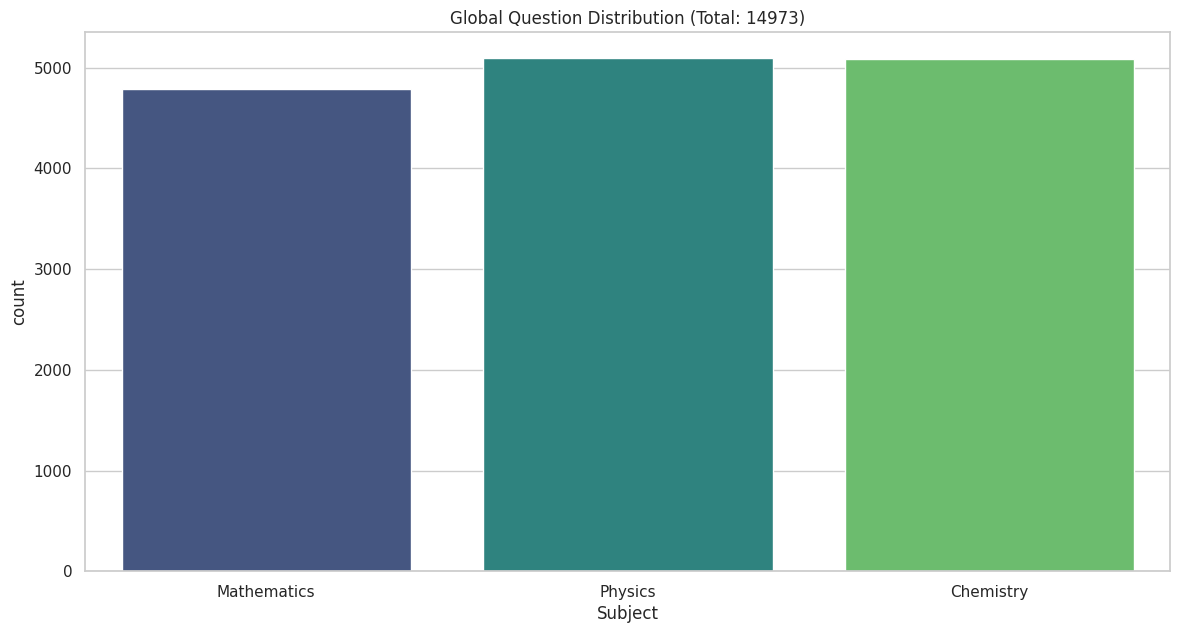

In [ ]:
plt.figure()
sns.countplot(data=df, x='Subject', palette='viridis')
plt.title(f'Global Question Distribution (Total: {len(df)})')
plt.show()


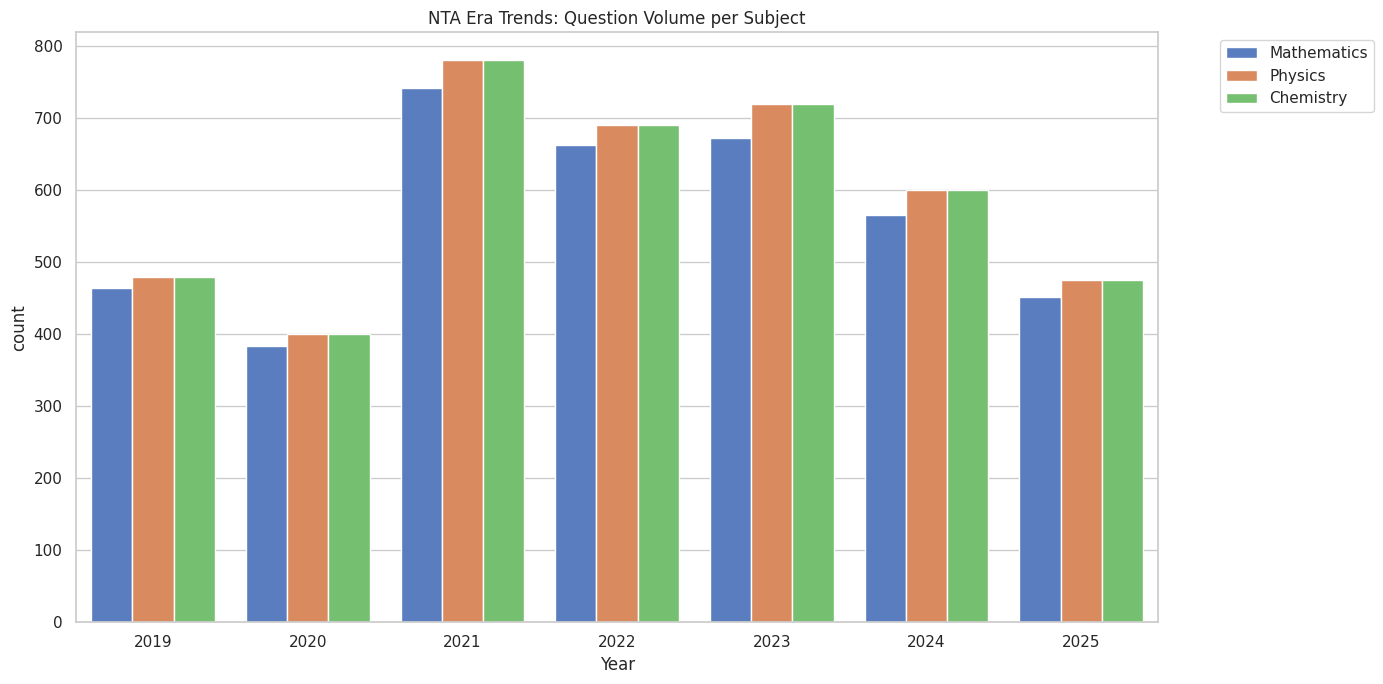

In [ ]:
plt.figure()
nta_era = df[df['Year'] >= 2019]
sns.countplot(data=nta_era, x='Year', hue='Subject', palette='muted')
plt.title('NTA Era Trends: Question Volume per Subject')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

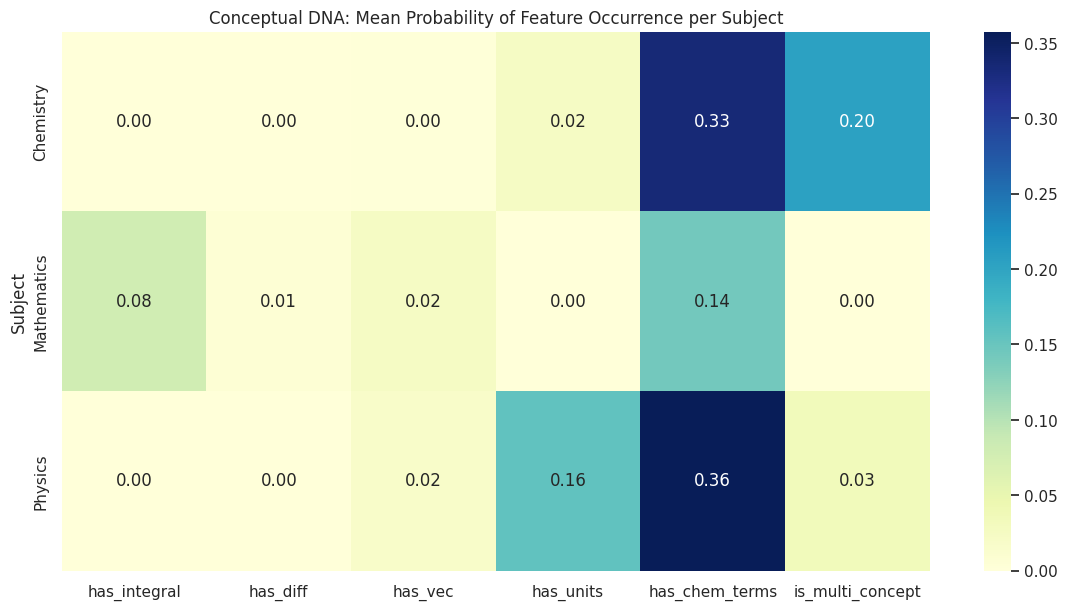

In [ ]:
plt.figure()
signal_cols = ['has_integral', 'has_diff', 'has_vec', 'has_units', 'has_chem_terms', 'is_multi_concept']
pivot_complexity = df.groupby('Subject')[signal_cols].mean()
sns.heatmap(pivot_complexity, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Conceptual DNA: Mean Probability of Feature Occurrence per Subject')
plt.show()


/tmp/ipykernel_30564/4180622012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette='rocket')


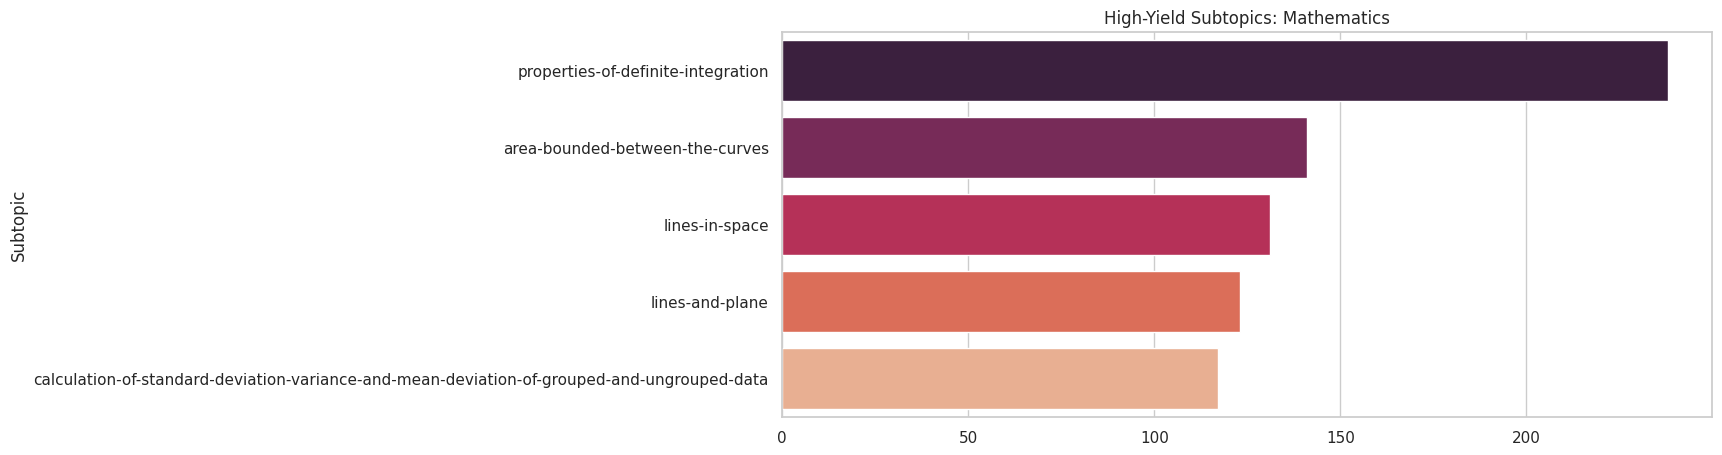

/tmp/ipykernel_30564/4180622012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette='rocket')


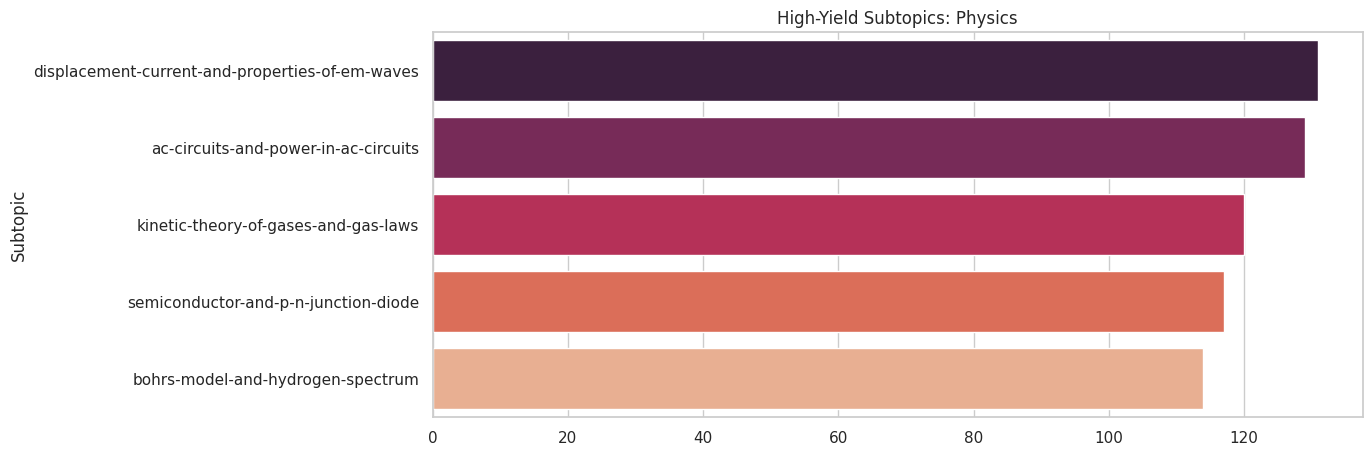

/tmp/ipykernel_30564/4180622012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette='rocket')


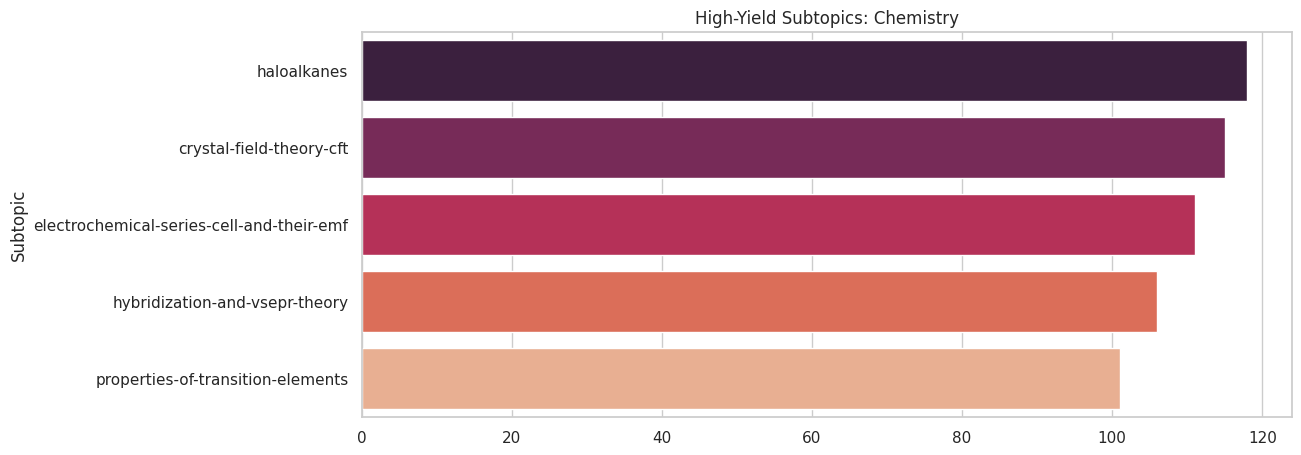

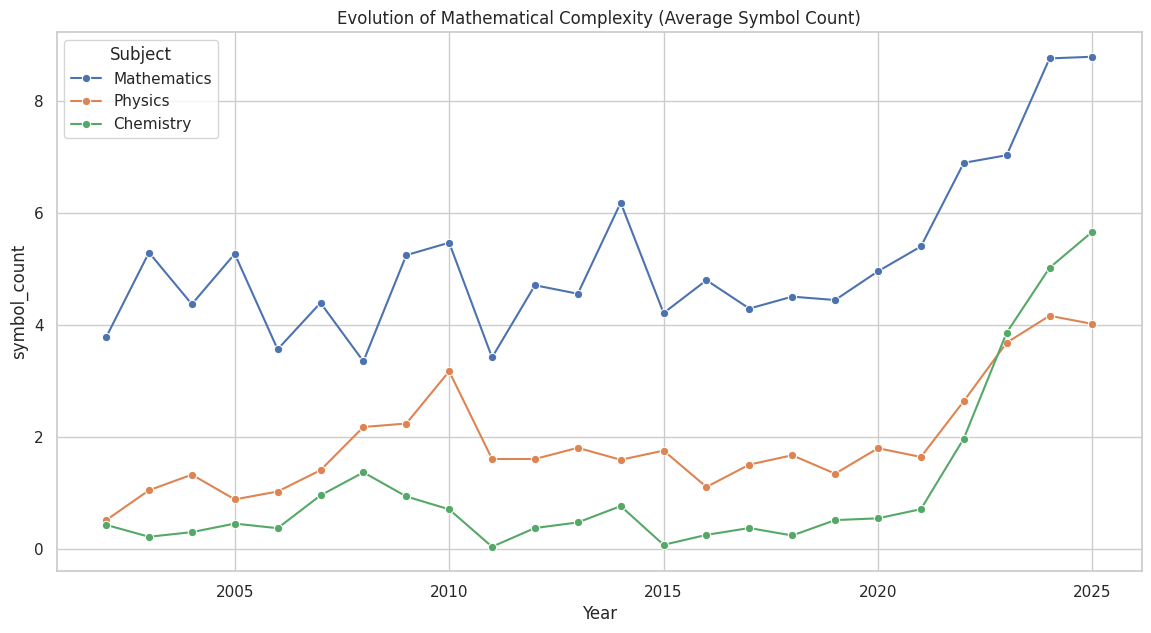

In [ ]:
for subj in df['Subject'].unique():
    plt.figure(figsize=(12, 5))
    subj_data = df[df['Subject'] == subj]
    top_topics = subj_data['Subtopic'].value_counts().nlargest(5)
    sns.barplot(x=top_topics.values, y=top_topics.index, palette='rocket')
    plt.title(f'High-Yield Subtopics: {subj}')
    plt.show()

# E. Complexity Evolution
plt.figure()
sns.lineplot(data=df, x='Year', y='symbol_count', hue='Subject', errorbar=None, marker='o')
plt.title('Evolution of Mathematical Complexity (Average Symbol Count)')
plt.show()

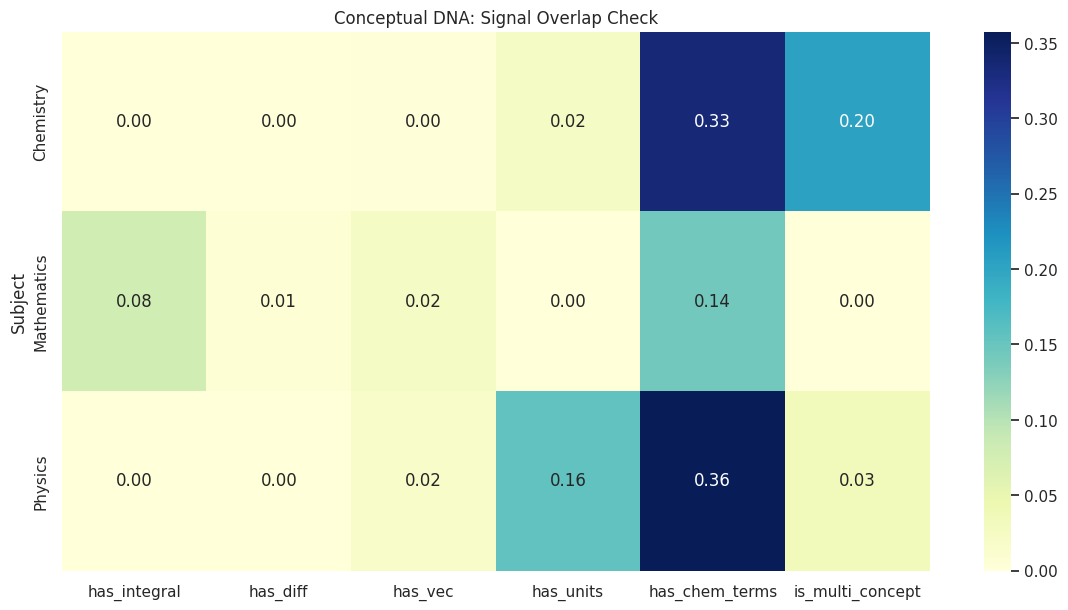

In [ ]:
plt.figure()
signal_cols = ['has_integral', 'has_diff', 'has_vec', 'has_units', 'has_chem_terms', 'is_multi_concept']
pivot_complexity = df.groupby('Subject')[signal_cols].mean()
sns.heatmap(pivot_complexity, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Conceptual DNA: Signal Overlap Check')
plt.show()


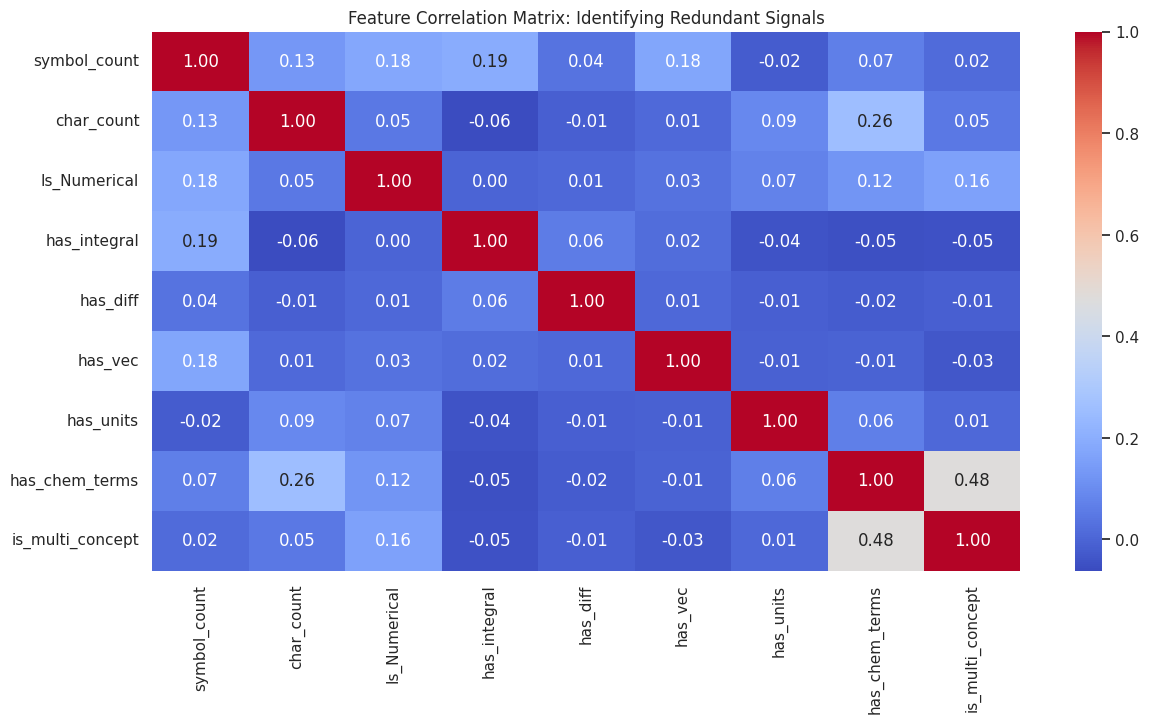

In [ ]:
plt.figure()
numeric_features = ['symbol_count', 'char_count', 'Is_Numerical'] + signal_cols
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix: Identifying Redundant Signals')
plt.show()

In [ ]:
t_df=df.dropna(subset=['Year'])

In [ ]:
t_df['Subject'].value_counts()

,count
Subject,
Physics,5097
Chemistry,5088
Mathematics,4788


In [ ]:
t_df['Year'] = t_df['Year'].astype(int)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
print("🧪 Generating Naive Bayes Subject Probability Features...")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = vectorizer.fit_transform(t_df['Raw_Latex'])

🧪 Generating Naive Bayes Subject Probability Features...


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_tfidf, t_df['Subject'])

MultinomialNB()

In [ ]:
nb_probs = nb_model.predict_proba(X_tfidf)
# We take the max probability as a 'Subject Confidence Score'
t_df['NB_Subject_Score'] = np.max(nb_probs, axis=1)

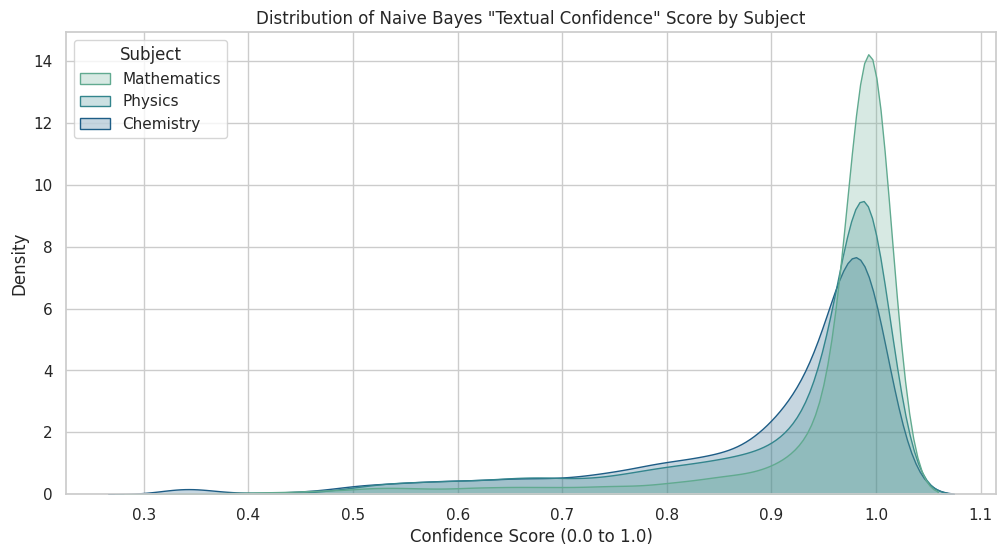

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=t_df, x='NB_Subject_Score', hue='Subject', fill=True, common_norm=False, palette='crest')
plt.title('Distribution of Naive Bayes "Textual Confidence" Score by Subject')
plt.xlabel('Confidence Score (0.0 to 1.0)')
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
print("⏳ Engineering Time-Series Lags and Recurrence Gaps...")
topic_yearly = t_df.groupby(['Subject', 'Chapter', 'Subtopic', 'Year']).agg({
    'symbol_count': 'mean',
    'char_count': 'mean',
    'NB_Subject_Score': 'mean',
    'has_integral': 'max',
    'has_diff': 'max',
    'Is_Numerical': 'max',
    'Raw_Latex': 'count'
}).rename(columns={'Raw_Latex': 'yearly_frequency'}).reset_index()

topic_yearly = topic_yearly.sort_values(['Subtopic', 'Year'])

⏳ Engineering Time-Series Lags and Recurrence Gaps...


In [ ]:
topic_yearly

,Subject,Chapter,Subtopic,Year,symbol_count,char_count,has_integral,has_diff,is_multi_concept,Is_Numerical,yearly_frequency
0,Chemistry,alcohols-phenols-and-ethers,properties-preparation-and-uses-of-alcohols,2003,0.000,114.00,0,0,0,0,1
1,Chemistry,alcohols-phenols-and-ethers,properties-preparation-and-uses-of-alcohols,2004,0.000,99.00,0,0,0,0,2
2,Chemistry,alcohols-phenols-and-ethers,properties-preparation-and-uses-of-alcohols,2005,0.000,72.50,0,0,0,0,2
3,Chemistry,alcohols-phenols-and-ethers,properties-preparation-and-uses-of-alcohols,2006,0.000,108.00,0,0,0,0,1
4,Chemistry,alcohols-phenols-and-ethers,properties-preparation-and-uses-of-alcohols,2007,14.000,319.00,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4570,Physics,work-power-and-energy,work,2021,1.500,224.75,0,0,0,1,4
4571,Physics,work-power-and-energy,work,2022,2.500,1367.00,0,0,0,0,2
4572,Physics,work-power-and-energy,work,2023,3.375,397.75,0,0,0,1,8
4573,Physics,work-power-and-energy,work,2024,4.000,498.40,0,0,0,1,5


In [ ]:
# Gap Feature: Years since last appearance
topic_yearly['last_appearance'] = topic_yearly.groupby('Subtopic')['Year'].shift(1)
topic_yearly['years_since_last'] = topic_yearly['Year'] - topic_yearly['last_appearance']
topic_yearly['years_since_last'] = topic_yearly['years_since_last'].fillna(10)

In [ ]:
# Target: 1 if subtopic appears next year
topic_yearly['target'] = topic_yearly.groupby('Subtopic')['Year'].shift(-1).apply(lambda x: 1 if not pd.isna(x) else 0)



/tmp/ipykernel_1544/1408185703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=topic_yearly, x='target', y='NB_Subject_Score', palette='Set2')


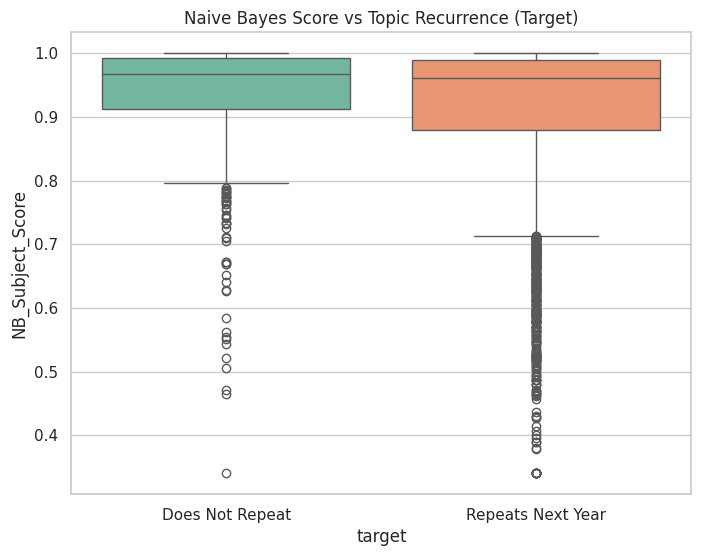

In [ ]:
# --- VISUALIZATION: NB SCORE VS RECURRENCE ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=topic_yearly, x='target', y='NB_Subject_Score', palette='Set2')
plt.title('Naive Bayes Score vs Topic Recurrence (Target)')
plt.xticks([0, 1], ['Does Not Repeat', 'Repeats Next Year'])
plt.show()

In [ ]:
df=pd.read_csv("/content/jee_full_dataset.csv")

In [ ]:
df.columns

Index(['Subject', 'Chapter', 'Subtopic', 'Year', 'Raw_Latex', 'Is_Numerical',
       'symbol_count', 'char_count', 'has_integral', 'has_diff', 'has_vec',
       'has_units', 'has_chem_terms', 'is_multi_concept'],
      dtype='object')

In [1]:
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
final_forecast.columns

Index(['Subject', 'Subtopic', 'Final_Prob', 'Is_Hit', 'Matched_With',
       'Match_Score'],
      dtype='object')

In [ ]:
d=pd.read_csv("/content/jee_2026.csv")

In [ ]:
d.columns

Index(['Subject', 'Chapter', 'Subtopic', 'Year', 'Raw_Latex', 'Is_Numerical',
       'symbol_count', 'char_count', 'has_integral', 'has_diff', 'has_vec',
       'has_units', 'has_chem_terms', 'is_multi_concept'],
      dtype='object')

In [3]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from thefuzz import fuzz, process
from jee_data_base import DataBase

warnings.filterwarnings("ignore")

# =============================================================================
# CONSTANTS
# =============================================================================
TRAIN_CUTOFF_YEAR   = 2023   # experts trained on data BEFORE this year
META_YEARS = [2019, 2020, 2021, 2022, 2023] # FIX 3: meta-manager needs both 0 and 1 targets
                                    # 2022 rows check if topic appeared in 2023 (exists)
                                    # 2023 rows check if topic appeared in 2024 (exists)
                                    # → both classes present, no ValueError
INFERENCE_YEAR      = 2026
TOP_K_PER_SUBJECT   = 30
SUBJECTS            = ["Physics", "Chemistry", "Mathematics"]
ARTIFACTS_DIR       = "."          # all .pkl and .csv saved here


# =============================================================================
# 1. SUBJECT EXPERT
# =============================================================================
class SubjectExpert:
    """
    Level-0 specialist for one JEE subject.

    Internal pipeline:
        vectorizer  → TF-IDF on raw LaTeX
        nb_purity   → MultinomialNB: measures how 'pure' a subtopic's language is
        knn_template→ KNN cosine: finds structurally similar historical questions
        clf         → calibrated primary classifier (SVM / RF / XGB)
        scaler      → StandardScaler fitted ONLY on this subject's train rows
                      FIX 1: all numeric features are scaled before clf and knn
    """

    def __init__(self, subject_name: str, model_type: str = "xgb"):
        self.subject_name = subject_name
        self.model_type   = model_type

        self.vectorizer    = TfidfVectorizer(max_features=500, stop_words="english")
        self.nb_purity     = MultinomialNB()
        self.knn_template  = KNeighborsClassifier(metric="cosine")  # n_neighbors set in train()
        self.scaler        = StandardScaler()                        # FIX 1

        if model_type == "svm":
            base_clf = SVC(probability=True, kernel="linear", random_state=42)
        elif model_type == "rf":
            base_clf = RandomForestClassifier(
                n_estimators=150, max_depth=12, random_state=42
            )
        else:
            base_clf = XGBClassifier(
                n_estimators=150, learning_rate=0.05, max_depth=6,
                random_state=42, verbosity=0
            )

        self.clf = CalibratedClassifierCV(estimator=base_clf, method="sigmoid", cv=3)

    # ------------------------------------------------------------------
    def train(self, df_subj: pd.DataFrame, features: list, target: str):
        if df_subj.empty:
            raise ValueError(f"No training data for {self.subject_name}")

        # A. Text heuristics (TF-IDF space — not scaled, NB/KNN need raw counts/tfidf)
        X_text = self.vectorizer.fit_transform(df_subj["Raw_Latex"])
        self.nb_purity.fit(X_text, df_subj["Subtopic"])

        # FIX 1b: KNN n_neighbors capped at available samples to avoid silent bias
        n_neighbors = min(5, len(df_subj))
        self.knn_template.set_params(n_neighbors=n_neighbors)
        self.knn_template.fit(X_text, df_subj[target])

        # B. Scale numeric features — fit scaler HERE, on training rows only
        X_num = self.scaler.fit_transform(df_subj[features])

        # C. Primary trend model on scaled features
        self.clf.fit(X_num, df_subj[target])

        n_pos = df_subj[target].sum()
        n_neg = len(df_subj) - n_pos
        print(f"   {self.subject_name}: {len(df_subj)} rows | target 1={n_pos} 0={n_neg}")

    # ------------------------------------------------------------------
    def get_signals(
        self, df_input: pd.DataFrame, features: list
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Returns three signal arrays (length = len(df_input)):
            prob_main   — primary clf probability of target=1
            prob_knn    — KNN template similarity score
            score_purity— NB max-class probability (topic language purity)
        """
        # FIX 1c: use the SAME scaler fitted on training data
        X_num_scaled = self.scaler.transform(df_input[features])
        prob_main    = self.clf.predict_proba(X_num_scaled)[:, 1]

        X_text_input = self.vectorizer.transform(df_input["Raw_Latex"])
        prob_knn     = self.knn_template.predict_proba(X_text_input)[:, 1]
        score_purity = np.max(self.nb_purity.predict_proba(X_text_input), axis=1)

        return prob_main, prob_knn, score_purity


# =============================================================================
# 2. DATA PREPARATION
# =============================================================================
def prepare_hierarchical_data() -> tuple[pd.DataFrame, LabelEncoder]:
    print("Extracting and partitioning JEE dataset...")
    db   = DataBase()
    rows = []

    for chap_name, chap in db.chapters_dict.items():
        subj = getattr(chap, "parent_subject", "Unknown").title()
        for q_id, q in getattr(chap, "question_dict", {}).items():
            latex = getattr(q, "question", "")
            if not latex:
                continue
            rows.append({
                "Subject"      : subj,
                "Chapter"      : chap_name,
                "Subtopic"     : getattr(q, "topic", "Unknown"),
                "Year"         : int(q.year) if hasattr(q, "year") and q.year else 2024,
                "Raw_Latex"    : latex,
                "symbol_count" : len(re.findall(r"\\[a-zA-Z]+", latex)),
                "Is_Numerical" : 1 if "integer" in getattr(q, "type", "").lower() else 0,
            })

    df = pd.DataFrame(rows)
    weights = df.groupby("Subtopic").size().to_dict()
    df["Historical_Weight"] = df["Subtopic"].map(weights)

    topic_yearly = (
        df.groupby(["Subject", "Chapter", "Subtopic", "Year"])
        .agg(
            symbol_count      = ("symbol_count",     "mean"),
            Historical_Weight = ("Historical_Weight", "max"),
            Is_Numerical      = ("Is_Numerical",       "max"),
            Raw_Latex         = ("Raw_Latex",         "first"),
        )
        .reset_index()
    )

    topic_yearly = topic_yearly.sort_values(["Subtopic", "Year"])
    topic_yearly["years_since_last"] = (
        topic_yearly["Year"]
        - topic_yearly.groupby("Subtopic")["Year"].shift(1)
    ).fillna(10)

    # Build appears from the FULL dataset so year Y can check if Y+1 exists.
    # This is NOT leakage for the experts — train_exp is still cutoff separately.
    # It only allows the target label itself to be computed correctly.
    appears = topic_yearly.groupby("Subtopic")["Year"].apply(set).to_dict()

    topic_yearly["target"] = topic_yearly.apply(
        lambda r: 1 if (r["Year"] + 1) in appears.get(r["Subtopic"], set()) else 0,
        axis=1,
    )

    # LabelEncoder fitted only on training chapters
    train_chapters = topic_yearly[topic_yearly["Year"] < TRAIN_CUTOFF_YEAR]["Chapter"]
    le_chap = LabelEncoder()
    le_chap.fit(train_chapters)

    known_chapters = set(le_chap.classes_)
    topic_yearly["Chapter_Code"] = topic_yearly["Chapter"].apply(
        lambda c: le_chap.transform([c])[0] if c in known_chapters else 0
    )

    print(f"   Dataset: {len(topic_yearly)} topic-year rows | "
          f"{topic_yearly['Subtopic'].nunique()} unique subtopics")
    print(f"   Target distribution: "
          f"1={topic_yearly['target'].sum()} / 0={(topic_yearly['target']==0).sum()}")

    return topic_yearly, le_chap


# =============================================================================
# 3. BUILD META-FEATURES
# =============================================================================
def build_meta_features(
    data: pd.DataFrame,
    experts: dict,
    features: list,
    meta_years: list,
) -> pd.DataFrame:
    """
    FIX 3: Use META_YEARS (e.g. 2022, 2023) as the meta-training window.
    These rows have target labels that check against 2023/2024 which exist
    in the dataset, so both class 0 and class 1 are present.
    """
    meta_pool = data[data["Year"].isin(meta_years)]
    print(f"   Meta pool: {len(meta_pool)} rows | "
          f"target 1={meta_pool['target'].sum()} 0={(meta_pool['target']==0).sum()}")

    if meta_pool["target"].nunique() < 2:
        raise ValueError(
            "Meta-training set has only one class. "
            "Expand META_YEARS or add more historical data."
        )

    meta_rows = []
    for _, row in meta_pool.iterrows():
        subj = row["Subject"]
        if subj not in experts:
            continue
        exp              = experts[subj]
        p_main, p_knn, s_purity = exp.get_signals(pd.DataFrame([row]), features)
        meta_rows.append({
            "p_main"   : p_main[0],
            "p_knn"    : p_knn[0],
            "s_purity" : s_purity[0],
            "weight"   : row["Historical_Weight"],
            "target"   : row["target"],
        })

    return pd.DataFrame(meta_rows)


# =============================================================================
# 4. INFERENCE FOR 2026
# =============================================================================
def build_2026_base(data: pd.DataFrame, le_chap: LabelEncoder) -> pd.DataFrame:
    """
    FIX (Bug 5 from previous analysis):
    Group by ['Subject', 'Subtopic'] — not just 'Subtopic' — so cross-subject
    contamination of years_since_last is impossible.
    """
    jan_2026 = (
        data.sort_values("Year")
        .groupby(["Subject", "Subtopic"], as_index=False)
        .tail(1)
        .copy()
    )
    jan_2026["years_since_last"] = INFERENCE_YEAR - jan_2026["Year"]
    jan_2026["Year"]             = INFERENCE_YEAR

    # Re-encode Chapter_Code for inference rows using the SAVED encoder
    known_chapters = set(le_chap.classes_)
    jan_2026["Chapter_Code"] = jan_2026["Chapter"].apply(
        lambda c: le_chap.transform([c])[0] if c in known_chapters else 0
    )

    return jan_2026


# =============================================================================
# 5. MAIN EXECUTION PIPELINE
# =============================================================================
def run_system():
    # --- 5.1 DATA ---
    data, le_chap = prepare_hierarchical_data()

    features = [
        "Chapter_Code", "Year", "symbol_count",
        "Historical_Weight", "Is_Numerical", "years_since_last",
    ]
    train_exp = data[data["Year"] < TRAIN_CUTOFF_YEAR]

    # --- 5.2 TRAIN LEVEL-0 EXPERTS ---
    print("\nTraining Level-0 Subject Experts...")
    experts = {
        "Physics"    : SubjectExpert("Physics",     model_type="svm"),
        "Chemistry"  : SubjectExpert("Chemistry",   model_type="rf"),
        "Mathematics": SubjectExpert("Mathematics", model_type="xgb"),
    }
    for name, expert in experts.items():
        expert_data = train_exp[train_exp["Subject"] == name]
        expert.train(expert_data, features, "target")

    # --- 5.3 BUILD META-FEATURES AND TRAIN MANAGER ---
    print("\nBuilding Level-1 meta-features for Manager...")
    df_meta = build_meta_features(data, experts, features, META_YEARS)

    meta_scaler  = StandardScaler()                        # FIX 1: scale meta inputs too
    meta_features = ["p_main", "p_knn", "s_purity", "weight"]
    X_meta = meta_scaler.fit_transform(df_meta[meta_features])

    manager = CalibratedClassifierCV(
        estimator=LogisticRegression(max_iter=500), cv=3   # cv=3 safer than cv=2
    )
    manager.fit(X_meta, df_meta["target"])
    print(f"   Manager trained. Classes: {manager.classes_}")

    # --- 5.4 INFERENCE ---
    print(f"\nProjecting syllabus into {INFERENCE_YEAR} environment...")
    jan_2026 = build_2026_base(data, le_chap)

    final_preds = []
    for _, row in jan_2026.iterrows():
        subj = row["Subject"]
        if subj not in experts:
            continue
        exp              = experts[subj]
        p_m, p_k, s_p   = exp.get_signals(pd.DataFrame([row]), features)
        meta_input       = meta_scaler.transform(
            [[p_m[0], p_k[0], s_p[0], row["Historical_Weight"]]]
        )
        final_prob = manager.predict_proba(meta_input)[0][1]
        final_preds.append({
            "Subject"   : subj,
            "Chapter"   : row["Chapter"],
            "Subtopic"  : row["Subtopic"],
            "Final_Prob": round(final_prob, 4),
        })

    df_2026 = pd.DataFrame(final_preds)

    # --- 5.5 BLUEPRINT FILTER: top-K per subject ---
    balanced_picks = []
    for s in SUBJECTS:
        top = (
            df_2026[df_2026["Subject"] == s]
            .sort_values("Final_Prob", ascending=False)
            .head(TOP_K_PER_SUBJECT)
        )
        balanced_picks.append(top)
    final_forecast = pd.concat(balanced_picks).reset_index(drop=True)

    # --- 5.6 SAVE ARTIFACTS ---
    print("\nSaving artifacts...")
    joblib.dump(experts,      f"{ARTIFACTS_DIR}/trained_experts.pkl")
    joblib.dump(manager,      f"{ARTIFACTS_DIR}/meta_manager.pkl")
    joblib.dump(meta_scaler,  f"{ARTIFACTS_DIR}/meta_scaler.pkl")
    joblib.dump(le_chap,      f"{ARTIFACTS_DIR}/label_encoder.pkl")   # FIX 2
    final_forecast.to_csv(    f"{ARTIFACTS_DIR}/final_forecast_2026.csv", index=False)
    print("   Saved: trained_experts.pkl, meta_manager.pkl, "
          "meta_scaler.pkl, label_encoder.pkl, final_forecast_2026.csv")

    # --- 5.7 OPTIONAL VALIDATION (if jee_2026.csv exists) ---
    try:
        print("\nPerforming subject-aware fuzzy validation...")
        gt_2026 = pd.read_csv("jee_2026.csv")

        def get_fuzzy_results(row, gt_df, threshold=70):
            mask       = gt_df["Subject"].str.lower() == str(row["Subject"]).lower()
            subject_gt = gt_df[mask]["Subtopic"].unique().tolist()
            if not subject_gt:
                return 0, "No subject match", 0
            res = process.extractOne(
                str(row["Subtopic"]), subject_gt,
                scorer=fuzz.partial_token_sort_ratio
            )
            if res:
                return (1 if res[1] >= threshold else 0), res[0], res[1]
            return 0, "No match", 0

        results = final_forecast.apply(
            lambda r: get_fuzzy_results(r, gt_2026), axis=1
        )
        final_forecast["Is_Hit"], final_forecast["Matched_With"], final_forecast["Match_Score"] = zip(*results)

        total_predicted = len(final_forecast)   # FIX: honest precision denominator
        hits            = final_forecast["Is_Hit"].sum()
        precision       = (hits / total_predicted) * 100
        recall_approx   = (hits / 90) * 100      # 90 = approx paper questions

        print("\n" + "=" * 50)
        print(f"  Precision : {precision:.1f}%  ({hits}/{total_predicted} predicted topics hit)")
        print(f"  Recall    : {recall_approx:.1f}%  ({hits}/90 paper topics covered)")
        print("=" * 50)

        per_subject = final_forecast.groupby("Subject")["Is_Hit"].agg(["sum", "count"])
        per_subject.columns = ["Hits", "Predicted"]
        per_subject["Precision%"] = (per_subject["Hits"] / per_subject["Predicted"] * 100).round(1)
        print("\nPer-subject breakdown:")
        print(per_subject.to_string())

        top10 = (
            final_forecast
            .sort_values("Final_Prob", ascending=False)
            [["Subject", "Chapter", "Subtopic", "Final_Prob", "Matched_With", "Match_Score", "Is_Hit"]]
            .head(10)
        )
        print("\nTop-10 predictions:")
        print(top10.to_string(index=False))

        # Save validated forecast
        final_forecast.to_csv(f"{ARTIFACTS_DIR}/final_forecast_2026_validated.csv", index=False)

    except FileNotFoundError:
        print("   jee_2026.csv not found — validation skipped. "
              "Forecast saved to final_forecast_2026.csv")
    except Exception as e:
        print(f"   Validation error: {e}")

    return final_forecast


# =============================================================================
if __name__ == "__main__":
    forecast = run_system()
    print(f"\nDone. {len(forecast)} topics in final forecast.")

Extracting and partitioning JEE dataset...
Unpickling: core.chapter Chapter
Unpickling: core.question Question
   Dataset: 4575 topic-year rows | 471 unique subtopics
   Target distribution: 1=2931 / 0=1644

Training Level-0 Subject Experts...
   Physics: 1136 rows | target 1=789 0=347
   Chemistry: 1215 rows | target 1=797 0=418
   Mathematics: 1177 rows | target 1=761 0=416

Building Level-1 meta-features for Manager...
   Meta pool: 1837 rows | target 1=1566 0=271
   Manager trained. Classes: [0 1]

Projecting syllabus into 2026 environment...

Saving artifacts...
   Saved: trained_experts.pkl, meta_manager.pkl, meta_scaler.pkl, label_encoder.pkl, final_forecast_2026.csv

Performing subject-aware fuzzy validation...

  Precision : 61.1%  (55/90 predicted topics hit)
  Recall    : 61.1%  (55/90 paper topics covered)

Per-subject breakdown:
             Hits  Predicted  Precision%
Subject                                 
Chemistry      17         30        56.7
Mathematics    18      